# 📊 Ericsson Patent Data — End-to-End ML Pipeline

> **Dataset:** Ericsson Innovation Timeline & Patent Evolution  
> **Task:** Predict `target_patent_count_next_quarter` (regression)  
> **Source:** [Kaggle – adamvakar](https://www.kaggle.com/datasets/adamvakar/ericsson-innovation-timeline-patent-evolution)

---

## 🗺️ Notebook Roadmap

| Step | Section |
|------|---------|
| 1 | Setup & Imports |
| 2 | Load the Raw Dataset |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Data Cleaning |
| 5 | Feature Engineering, Encoding & Leakage Check |
| 6 | Group-Aware Train / Test Split |
| 7 | Model Training |
| 8 | Evaluation & Linearity Diagnostics |
| 9 | Hyperparameter Tuning |
| 10 | Final Model Decision & Interpretation |
| 11 | Domain-Specific Prediction |

---

> 💡 **Run every cell top-to-bottom.** Each section builds on the previous one.


---
## 🔧 Section 1 — Setup & Imports

We import every library we need in one place.  
This makes it easy to spot missing dependencies before running the rest of the notebook.


In [1]:
# Uncomment the line below on first run to install all required packages
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet



[notice] A new release of pip is available: 24.1.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ── Core libraries ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.model_selection import GridSearchCV, GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print('✅ All libraries imported successfully!')


✅ All libraries imported successfully!


---
## 📂 Section 2 — Load the Raw Dataset

### Why keep a raw copy?
We always preserve `df_raw` untouched throughout the notebook.  
- You can compare cleaned data against the original at any time.  
- You can restart cleaning from scratch without re-downloading.  
- It makes debugging much easier.


In [3]:
DATA_PATH = 'ericsson_patent_rich_dataset.csv'   # <- update path if needed
df_raw = pd.read_csv(DATA_PATH)
print(f'✅ Dataset loaded:  {df_raw.shape[0]:,} rows  ×  {df_raw.shape[1]} columns')


✅ Dataset loaded:  30,118 rows  ×  55 columns


In [4]:
df_raw.head()


,patent_id,patent_type,patent_date,patent_title,year,quarter,month,day_of_week,day_of_year,quarter_end,...,patent_count_lag4,patent_count_roll4_mean,patent_count_roll8_mean,patent_count_qoq,patent_count_yoy,target_patent_count_current,target_patent_count_next_quarter,years_since_first_patent,patent_seq_global,year_patent_count
0,3934093,utility,1976-01-20,Transit exchange for asynchronous data with un...,1976,1,1,1,20,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,1,36
1,3936612,utility,1976-02-03,Control and holding circuit for relay matrices,1976,1,2,1,34,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,3,36
2,3936781,utility,1976-02-03,Selecting device for crossbar switches,1976,1,2,1,34,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,2,36
3,3938025,utility,1976-02-10,DC to DC converter for producing two individua...,1976,1,2,1,41,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,5,36
4,3938040,utility,1976-02-10,Apparatus for measuring a signal voltage inclu...,1976,1,2,1,41,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,4,36


In [5]:
df_raw.dtypes


patent_id                               str
patent_type                             str
patent_date                             str
patent_title                            str
year                                  int64
quarter                               int64
month                                 int64
day_of_week                           int64
day_of_year                           int64
quarter_end                             str
title_len_chars                       int64
title_len_words                       int64
title_has_number                      int64
title_has_acronym                     int64
kw_5g                                 int64
kw_ai_ml                              int64
kw_cloud_edge                         int64
kw_security                           int64
kw_iot                                int64
kw_network                            int64
kw_energy                             int64
kw_antenna                            int64
kw_data                         

---
## 🔍 Section 3 — Exploratory Data Analysis (EDA)

EDA is like a health check for your dataset — we want to understand:
1. **Shape** — how many rows and columns?
2. **Missing values** — which columns have gaps?
3. **Distributions** — what do numeric features look like?
4. **Target variable** — is it skewed? Are there outliers?
5. **Linearity** — do key features relate linearly to the target?

> 🎓 EDA is about *understanding*, not cleaning yet.


In [6]:
# ── 3.1 Basic shape and info ─────────────────────────────────────────────────
print(f'Rows    : {df_raw.shape[0]:,}')
print(f'Columns : {df_raw.shape[1]}')
df_raw.info()


Rows    : 30,118
Columns : 55
<class 'pandas.DataFrame'>
RangeIndex: 30118 entries, 0 to 30117
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   patent_id                         30118 non-null  str    
 1   patent_type                       30118 non-null  str    
 2   patent_date                       30118 non-null  str    
 3   patent_title                      30118 non-null  str    
 4   year                              30118 non-null  int64  
 5   quarter                           30118 non-null  int64  
 6   month                             30118 non-null  int64  
 7   day_of_week                       30118 non-null  int64  
 8   day_of_year                       30118 non-null  int64  
 9   quarter_end                       30118 non-null  str    
 10  title_len_chars                   30118 non-null  int64  
 11  title_len_words                   30118 non-null

In [7]:
# ── 3.2 Statistical summary ───────────────────────────────────────────────────
# .T transposes the table so each row is a feature — easier to read
df_raw.describe().T


,count,mean,std,min,25%,50%,75%,max
year,30118.0,2013.233382,8.851538,1976.00,2008.000000,2015.000000,2020.000000,2025.000000
quarter,30118.0,2.514510,1.101261,1.00,2.000000,3.000000,3.000000,4.000000
month,30118.0,6.546185,3.381182,1.00,4.000000,7.000000,9.000000,12.000000
day_of_week,30118.0,1.000000,0.000000,1.00,1.000000,1.000000,1.000000,1.000000
day_of_year,30118.0,183.744638,103.281235,1.00,95.000000,184.000000,271.000000,366.000000
title_len_chars,30118.0,64.396142,29.750263,4.00,44.000000,60.000000,81.000000,268.000000
title_len_words,30118.0,8.820473,4.383788,1.00,6.000000,8.000000,11.000000,39.000000
title_has_number,30118.0,0.018594,0.135087,0.00,0.000000,0.000000,0.000000,1.000000
title_has_acronym,30118.0,0.162129,0.368575,0.00,0.000000,0.000000,0.000000,1.000000
kw_5g,30118.0,0.007205,0.084577,0.00,0.000000,0.000000,0.000000,1.000000


In [8]:
# ── 3.3 Missing value analysis ────────────────────────────────────────────────
# We count NaNs per column and express as a percentage of total rows
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df.to_string() if not missing_df.empty else '✅ No missing values found!')


                                  Missing Count  Missing %
target_patent_count_next_quarter            408       1.35


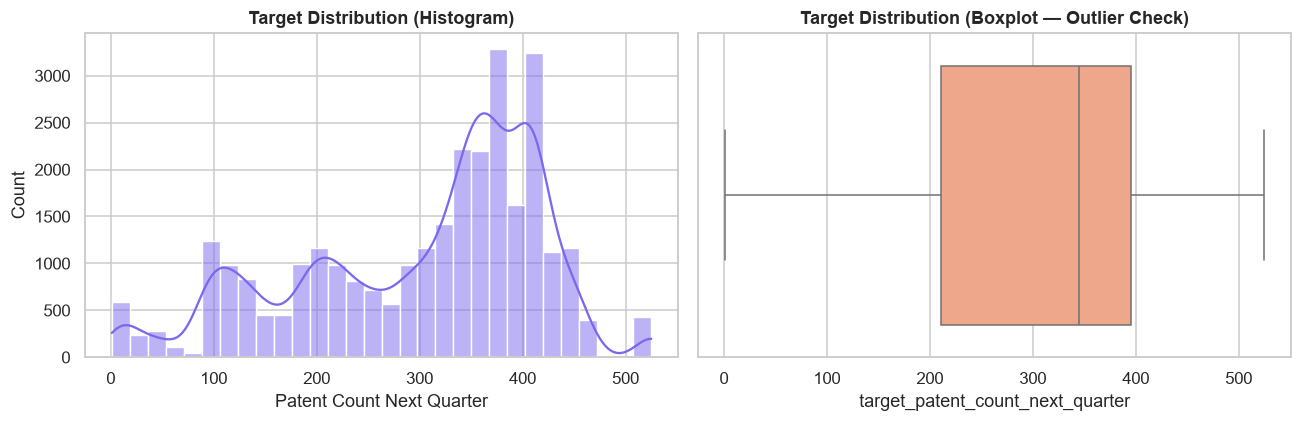

count    29710.000000
mean       300.642141
std        118.612862
min          1.000000
25%        211.000000
50%        345.000000
75%        395.000000
max        525.000000
Name: target_patent_count_next_quarter, dtype: float64


In [9]:
# ── 3.4 Target variable distribution ─────────────────────────────────────────
# We want to understand:
#   - Is the target normally distributed or skewed?
#   - Are there extreme outliers (very high patent counts)?
# A histogram shows the shape; a boxplot highlights outliers.

target = 'target_patent_count_next_quarter'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_raw[target].dropna(), bins=30, kde=True, color='mediumslateblue', ax=axes[0])
axes[0].set_title('Target Distribution (Histogram)', fontweight='bold')
axes[0].set_xlabel('Patent Count Next Quarter')
sns.boxplot(x=df_raw[target].dropna(), color='lightsalmon', ax=axes[1])
axes[1].set_title('Target Distribution (Boxplot — Outlier Check)', fontweight='bold')
plt.tight_layout()
plt.show()
print(df_raw[target].describe())


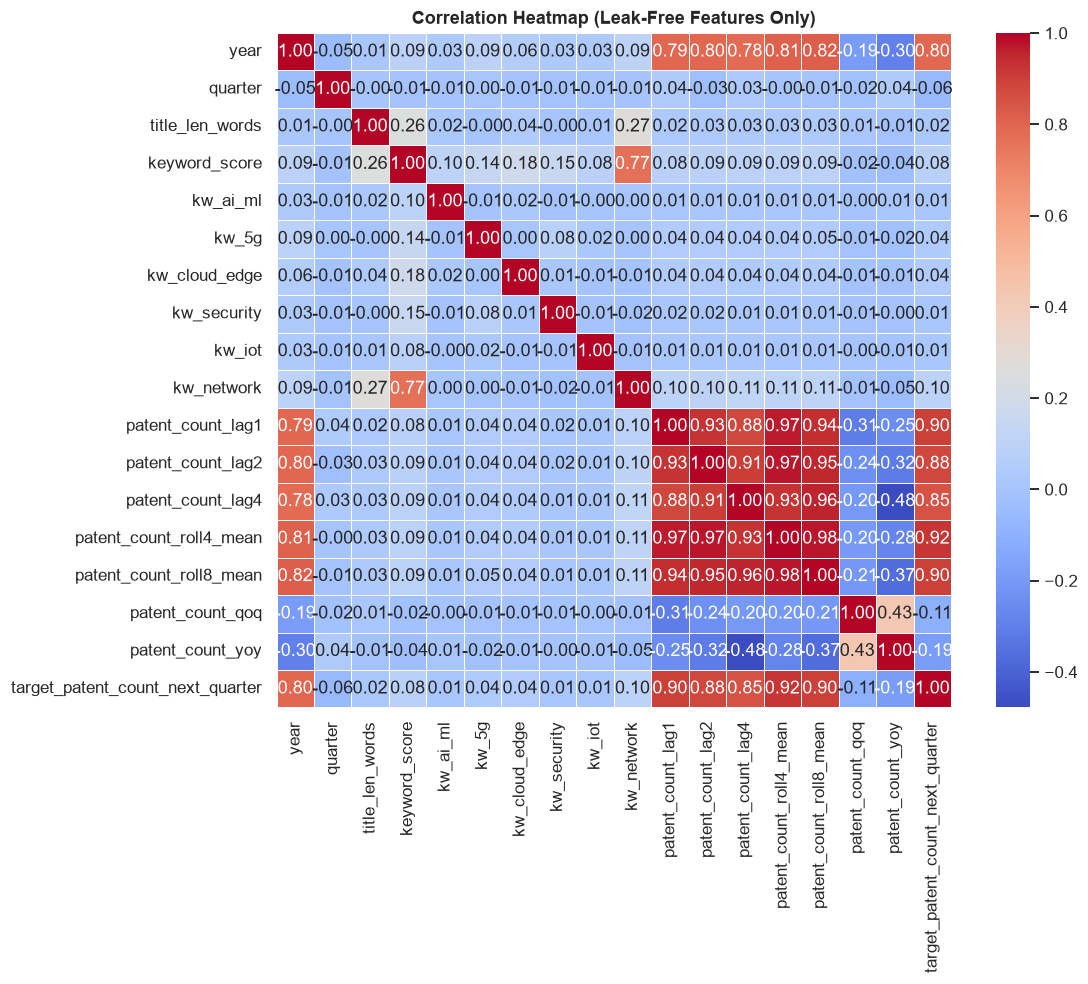

In [10]:
# ── 3.5 Correlation heatmap (leak-free features only) ────────────────────────
# We only include features that are safe to use at prediction time.
# Leaky features (those that encode future information) are deliberately excluded.
# See Section 5 for the full leakage explanation.

SAFE_FEATURES = [
    'year', 'quarter', 'title_len_words', 'keyword_score',
    'kw_ai_ml', 'kw_5g', 'kw_cloud_edge', 'kw_security', 'kw_iot', 'kw_network',
    'patent_count_lag1', 'patent_count_lag2', 'patent_count_lag4',
    'patent_count_roll4_mean', 'patent_count_roll8_mean',
    'patent_count_qoq', 'patent_count_yoy'
]

corr_safe = df_raw[SAFE_FEATURES + [target]].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_safe, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.4, square=True)
plt.title('Correlation Heatmap (Leak-Free Features Only)', fontweight='bold')
plt.tight_layout()
plt.show()


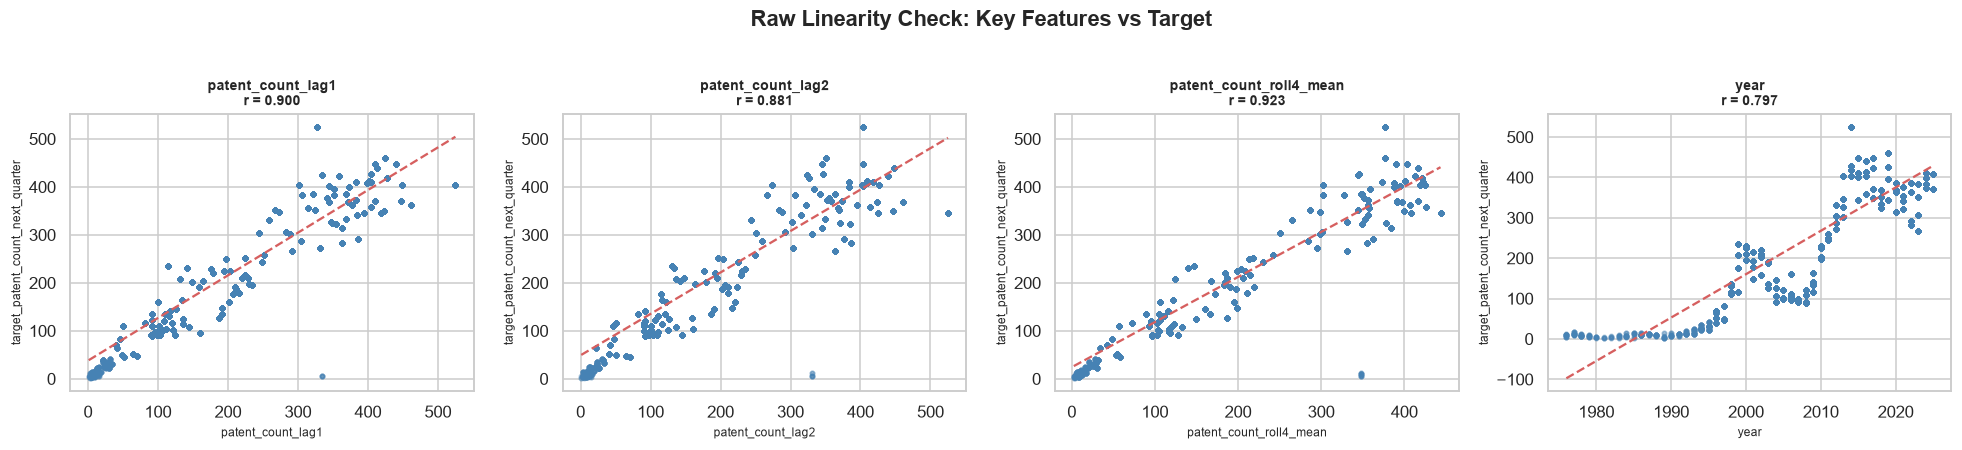

In [11]:
# ── 3.6 Scatter plots: do key features relate linearly to the target? ─────────
# If points follow the red dashed line closely → strong linear relationship.
# If points curve or fan out → non-linearity is present.
# The correlation value r tells us direction and strength (-1 to +1).

lag_feats = ['patent_count_lag1', 'patent_count_lag2', 'patent_count_roll4_mean', 'year']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, feat in zip(axes, lag_feats):
    df_plot = df_raw[[feat, target]].dropna()
    ax.scatter(df_plot[feat], df_plot[target], alpha=0.15, s=8, color='steelblue')
    z = np.polyfit(df_plot[feat], df_plot[target], 1)
    p = np.poly1d(z)
    xs = np.linspace(df_plot[feat].min(), df_plot[feat].max(), 200)
    ax.plot(xs, p(xs), 'r--', linewidth=1.5, label='Linear fit')
    r = df_plot[feat].corr(df_plot[target])
    title = f'{feat}\nr = {r:.3f}'
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel(target, fontsize=8)

plt.suptitle('Raw Linearity Check: Key Features vs Target', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 🧹 Section 4 — Data Cleaning

**Rule: Never modify `df_raw` directly.**  
We work on a copy called `df_clean`.

### What we fix:
1. **`patent_date`** — stored as a string, converted to proper datetime  
2. **Missing target rows** — most recent quarter has no future label yet; drop these  
3. **Verify** — confirm no duplicates or remaining nulls


In [12]:
# Always start from a fresh copy — never mutate df_raw!
df_clean = df_raw.copy()
print(f'Starting shape: {df_clean.shape}')


Starting shape: (30118, 55)


In [13]:
# ── 4.1 Fix date column dtype ─────────────────────────────────────────────────
# Pandas reads dates as strings by default. Converting to datetime lets us
# sort by date, extract components (month, day), and use date arithmetic.
df_clean['patent_date'] = pd.to_datetime(df_clean['patent_date'])
print('patent_date dtype after fix:', df_clean['patent_date'].dtype)


patent_date dtype after fix: datetime64[us]


In [14]:
# ── 4.2 Drop rows with missing target ────────────────────────────────────────
# WHY: The most recent quarter has no 'next quarter' data yet —
# the future hasn't happened, so the target is NaN.
# These rows are useless for supervised learning.

rows_before = len(df_clean)
df_clean = df_clean.dropna(subset=[target])
print(f'Rows removed (missing target): {rows_before - len(df_clean)}')
print(f'Remaining rows               : {len(df_clean):,}')


Rows removed (missing target): 408
Remaining rows               : 29,710


In [15]:
# ── 4.3 Final verification ────────────────────────────────────────────────────
print(f'Duplicates remaining : {df_clean.duplicated().sum()}')
nulls = df_clean.isnull().sum()
remaining = nulls[nulls > 0]
print(remaining.to_string() if not remaining.empty else '✅ No missing values!')


Duplicates remaining : 0
✅ No missing values!


---
## ⚙️ Section 5 — Feature Engineering, Encoding & Leakage Check

### ⚠️ Why R² was suspiciously close to 1 (and how we fixed it)

When you first build an ML model and get R² ≈ 1.0, **don't celebrate yet**.  
It almost always means **data leakage** — the model is accidentally seeing the answer.

**Leaky features in this dataset:**

| Column | Why it leaks |
|--------|-------------|
| `year_patent_count` | Total patents for that entire year — includes future quarters |
| `target_patent_count_current` | This quarter's count — directly correlated with next quarter |
| `patent_count`, `patent_unique` | Row-level aggregates computed at query time |
| `patent_seq_global` | Global filing order — encodes future volume |

**Fix:** Use only lag/rolling features — values computed from *past* quarters only.  
These are information a model would genuinely have at prediction time.

### ⚠️ Why GroupShuffleSplit instead of random split?

This dataset has **one row per patent** (~30k rows), but lag features like  
`patent_count_lag1` are identical for every patent in the same quarter.  

With a **random split**, patents from the same quarter end up in both train and test.  
The model memorises the shared lag values → R² = 1.0 again.  

**Fix:** `GroupShuffleSplit` ensures all patents from a given quarter go  
entirely to train OR entirely to test — never both.


In [16]:
# ── 5.1 Leakage audit ────────────────────────────────────────────────────────
# We compute correlations with the target to see how 'suspicious' each feature is.
# Anything above ~0.95 and not a lag feature is likely leaky.

LEAKY_COLS = [
    'year_patent_count',           # future-aware yearly aggregate
    'target_patent_count_current', # current quarter count — directly leaks
    'patent_count',                # row-level aggregate
    'patent_unique',               # same
    'patent_seq_global',           # filing order encodes future volume
]

numeric_cols = df_clean.select_dtypes(include='number').columns
corr_with_target = df_clean[numeric_cols].corr()[target].abs().sort_values(ascending=False)

print('Top 10 correlations with target (including leaky features):')
print(corr_with_target.head(10))
print()
print('Flagged as leaky → excluded from training:')
for c in LEAKY_COLS:
    val = corr_with_target.get(c, np.nan)
    print(f'  {c}: corr = {val:.3f}')


Top 10 correlations with target (including leaky features):
target_patent_count_next_quarter    1.000000
year_patent_count                   0.953959
patent_count                        0.929149
target_patent_count_current         0.929149
patent_unique                       0.929149
patent_count_roll4_mean             0.922757
kw_network_count                    0.907474
patent_count_lag1                   0.900422
patent_count_roll8_mean             0.899437
patent_count_lag2                   0.881407
Name: target_patent_count_next_quarter, dtype: float64

Flagged as leaky → excluded from training:
  year_patent_count: corr = 0.954
  target_patent_count_current: corr = 0.929
  patent_count: corr = 0.929
  patent_unique: corr = 0.929
  patent_seq_global: corr = 0.722


In [17]:
# ── 5.2 One-Hot Encode categorical columns ────────────────────────────────────
# ML models only understand numbers — not strings like 'utility' or 'modern_2020s'.
# One-Hot Encoding converts each category into a binary (0/1) column.
# drop_first=True removes one column per feature to avoid multicollinearity.

cat_cols_to_encode = ['patent_type', 'tech_era']
df_encoded = pd.get_dummies(df_clean, columns=cat_cols_to_encode, drop_first=True)

new_cols = [c for c in df_encoded.columns
            if any(c.startswith(cat) for cat in cat_cols_to_encode)]
print('New columns from One-Hot Encoding:')
for c in new_cols:
    print(f'  → {c}')


New columns from One-Hot Encoding:
  → patent_type_reissue
  → patent_type_utility
  → tech_era_legacy_pre_1990
  → tech_era_mobile_2000s
  → tech_era_modern_2020s
  → tech_era_smartphone_2010s


In [18]:
# ── 5.3 Select leak-free features ────────────────────────────────────────────
# These are the only features a model would have at prediction time:
#   quarter        : seasonal pattern
#   title signals  : title length, keyword score
#   domain flags   : 5G, AI/ML, cloud, security, iot, network
#   lag features   : patent counts from 1, 2, 4 quarters ago
#   rolling avgs   : smoothed recent trend (4-quarter and 8-quarter)
#   growth rates   : quarter-over-quarter and year-over-year change
# NOTE: 'year' is excluded — it acts as a proxy leak because patent counts
#       grow monotonically over time, making year almost equal to the target.

base_features = [
    'quarter',
    'title_len_words', 'keyword_score',
    'kw_ai_ml', 'kw_5g', 'kw_cloud_edge',
    'kw_security', 'kw_iot', 'kw_network',
    'patent_count_lag1', 'patent_count_lag2', 'patent_count_lag4',
    'patent_count_roll4_mean', 'patent_count_roll8_mean',
    'patent_count_qoq', 'patent_count_yoy'
]
encoded_cols = [c for c in df_encoded.columns
                if any(c.startswith(cat) for cat in cat_cols_to_encode)]
all_features = base_features + encoded_cols

TARGET = 'target_patent_count_next_quarter'

print(f'Total features selected : {len(all_features)}')
print(f'Base features           : {len(base_features)}')
print(f'Encoded features        : {len(encoded_cols)}')


Total features selected : 22
Base features           : 16
Encoded features        : 6


---
## ✂️ Section 6 — Group-Aware Train / Test Split & Scaling

### The same-quarter leakage problem

This dataset has ~30,000 rows but only ~198 unique quarters.  
Every patent in the same quarter shares identical lag features.

A **random split** would put patents from Q3-2018 in both train and test.  
The model would see the same lag values in training and testing → perfect memorisation.

### Solution: GroupShuffleSplit

`GroupShuffleSplit` treats each quarter as a **group**.  
All patents from a given quarter go **entirely** to train or **entirely** to test.  
This mirrors real-world deployment: train on past quarters, predict future ones.

### Feature Scaling

`StandardScaler` transforms each feature to mean=0, std=1.  
Critical for Ridge and Lasso — they penalise large coefficients,  
so unscaled features with large ranges would be unfairly penalised.  

> 🔑 Always fit the scaler on training data only, then apply to test.  
> Fitting on test data = data leakage.


In [19]:
# ── 6.1 Define row-level X and y ──────────────────────────────────────────────
X_row = df_encoded[all_features]
y_row = df_encoded[TARGET]

print(f'Row-level X shape : {X_row.shape}')
print(f'Row-level y shape : {y_row.shape}')


Row-level X shape : (29710, 22)
Row-level y shape : (29710,)


In [20]:
# ── 6.2 Group-aware split ────────────────────────────────────────────────────
# groups = a label for which quarter each row belongs to (e.g. '2018_Q3')
# GroupShuffleSplit ensures all rows with the same group label go to the same set.

groups = df_encoded['year'].astype(str) + '_Q' + df_encoded['quarter'].astype(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X_row, y_row, groups=groups))

X_train = X_row.iloc[train_idx]
X_test  = X_row.iloc[test_idx]
y_train = y_row.iloc[train_idx]
y_test  = y_row.iloc[test_idx]

print(f'Train rows           : {len(X_train):,}')
print(f'Test rows            : {len(X_test):,}')
print(f'Train unique quarters: {groups.iloc[train_idx].nunique()}')
print(f'Test unique quarters : {groups.iloc[test_idx].nunique()}')
print(f'Train target mean    : {y_train.mean():.2f}  std: {y_train.std():.2f}')
print(f'Test  target mean    : {y_test.mean():.2f}  std: {y_test.std():.2f}')


Train rows           : 23,812
Test rows            : 5,898
Train unique quarters: 158
Test unique quarters : 40
Train target mean    : 302.71  std: 119.91
Test  target mean    : 292.28  std: 112.84


In [21]:
# ── 6.3 Feature scaling (StandardScaler) ─────────────────────────────────────
# fit_transform on train: learns mean and std, then scales
# transform on test    : applies the SAME mean/std learned from train (no refit!)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Scaling complete.')
print(f'   Train mean (feature 0): {X_train_scaled[:, 0].mean():.4f}  (should be ≈ 0)')
print(f'   Train std  (feature 0): {X_train_scaled[:, 0].std():.4f}   (should be ≈ 1)')


✅ Scaling complete.
   Train mean (feature 0): -0.0000  (should be ≈ 0)
   Train std  (feature 0): 1.0000   (should be ≈ 1)


---
## 🤖 Section 7 — Model Training

We train five models and compare them:

| Model | Key Idea | Good for |
|-------|---------|----------|
| **Linear Regression** | Fits a straight-line hyperplane | Baseline; fully interpretable |
| **Ridge (L2)** | Linear + L2 penalty on coefficients | Correlated features; stable |
| **Lasso (L1)** | Linear + L1 penalty; can zero out features | Automatic feature selection |
| **Poly Ridge deg2** | Adds squared + interaction terms | Testing mild non-linearity |
| **Poly Ridge deg3** | Adds cubic terms | Testing stronger non-linearity |
| **Random Forest** | Ensemble of 200 decision trees | Non-linear relationships |

### Why Polynomial models MUST use Ridge regularisation

`PolynomialFeatures(degree=2)` on 20 features creates ~230 new features.  
Unregularised Linear Regression memorises all 230 → Train R²=1.0, Test R²→negative.  
Ridge regularisation penalises large coefficients, preventing this collapse.  
The extra `StandardScaler` inside the pipeline rescales the exploded polynomial features.


In [22]:
# ── 7.1 Define all models ─────────────────────────────────────────────────────

poly2_pipeline = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),     # rescale the ~230 polynomial features
    ('ridge',  Ridge(alpha=1000.0))   # strong regularisation prevents memorisation
])

poly3_pipeline = Pipeline([
    ('poly',   PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(alpha=10000.0))  # even stronger for degree 3 (more features)
])

models = {
    'Linear Regression' : LinearRegression(),
    'Ridge (L2)'        : Ridge(alpha=1.0),
    'Lasso (L1)'        : Lasso(alpha=0.1, max_iter=10000),
    'Poly Ridge deg2'   : poly2_pipeline,
    'Poly Ridge deg3'   : poly3_pipeline,
    'Random Forest'     : RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
}

print(f'Models to train: {list(models.keys())}')


Models to train: ['Linear Regression', 'Ridge (L2)', 'Lasso (L1)', 'Poly Ridge deg2', 'Poly Ridge deg3', 'Random Forest']


In [23]:
# ── 7.2 Train all models ──────────────────────────────────────────────────────
# Each model sees ONLY X_train_scaled.
# Test data is held out completely until evaluation in Section 8.

trained = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained[name] = model
    print(f'  ✅ Trained: {name}')

print('\nAll models trained!')


  ✅ Trained: Linear Regression
  ✅ Trained: Ridge (L2)
  ✅ Trained: Lasso (L1)
  ✅ Trained: Poly Ridge deg2
  ✅ Trained: Poly Ridge deg3
  ✅ Trained: Random Forest

All models trained!


---
## 📈 Section 8 — Evaluation & Linearity Diagnostics

### Metrics explained

| Metric | What it measures | Better when |
|--------|-----------------|-------------|
| **R²** | % of variance explained (1.0 = perfect) | Higher |
| **RMSE** | Root Mean Squared Error — penalises large errors heavily | Lower |
| **MAE** | Mean Absolute Error — average error in same units as target | Lower |
| **Overfit Gap** | Train R² − Test R² | Closer to 0 |

### Linearity decision logic

- If **Poly deg2 Test R² ≈ Linear Test R²** (gap < 0.005) → data is strongly linear; drop poly  
- If **Poly deg2 >> Linear** (gap ≥ 0.01) → non-linearity present; poly adds value  
- If **RF >> all linear models** → complex interactions exist; keep RF


In [24]:
# ── 8.1 Evaluate all models on train AND test ─────────────────────────────────
# We always check both train and test performance.
# Train R²=0.99 but Test R²=0.50 → badly overfit → useless in production.

results = []

for name, model in trained.items():
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test  = model.predict(X_test_scaled)

    train_r2 = r2_score(y_train, y_pred_train)
    test_r2  = r2_score(y_test,  y_pred_test)
    rmse     = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae      = mean_absolute_error(y_test, y_pred_test)
    overfit  = train_r2 - test_r2

    results.append({
        'Model'      : name,
        'Train R²'   : round(train_r2, 4),
        'Test R²'    : round(test_r2,  4),
        'Overfit Gap': round(overfit,  4),
        'RMSE'       : round(rmse, 4),
        'MAE'        : round(mae,  4),
    })

results_df = pd.DataFrame(results).sort_values('Test R²', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))


            Model  Train R²  Test R²  Overfit Gap    RMSE     MAE
    Random Forest    1.0000   0.7622       0.2378 55.0288 46.7861
       Lasso (L1)    0.9024   0.7076       0.1948 61.0135 48.7318
Linear Regression    0.9025   0.7021       0.2004 61.5889 49.3475
       Ridge (L2)    0.9025   0.7021       0.2004 61.5826 49.3416
  Poly Ridge deg3    0.9426   0.6820       0.2606 63.6339 50.4603
  Poly Ridge deg2    0.9411   0.6705       0.2705 64.7648 51.0687


In [25]:
# ── 8.2 Linearity diagnostic ──────────────────────────────────────────────────
# Key question: does adding polynomial terms actually improve predictions?
# If not → the relationship is already well-captured by a straight line.

lin_r2   = results_df.loc[results_df['Model'] == 'Linear Regression', 'Test R²'].values[0]
poly2_r2 = results_df.loc[results_df['Model'] == 'Poly Ridge deg2',   'Test R²'].values[0]
poly3_r2 = results_df.loc[results_df['Model'] == 'Poly Ridge deg3',   'Test R²'].values[0]
rf_r2    = results_df.loc[results_df['Model'] == 'Random Forest',     'Test R²'].values[0]

delta_poly2 = poly2_r2 - lin_r2   # gain from adding degree-2 terms
delta_poly3 = poly3_r2 - poly2_r2 # additional gain from degree-3 terms

print('=' * 55)
print('       LINEARITY DIAGNOSTIC SUMMARY')
print('=' * 55)
print(f'  Linear R²          : {lin_r2:.4f}')
print(f'  Poly deg2 R²       : {poly2_r2:.4f}  (gain over linear: {delta_poly2:+.4f})')
print(f'  Poly deg3 R²       : {poly3_r2:.4f}  (gain over deg2:  {delta_poly3:+.4f})')
print(f'  Random Forest R²   : {rf_r2:.4f}')
print('=' * 55)

LINEARITY_THRESHOLD = 0.005  # < 0.5 pp gain = negligible

if delta_poly2 < LINEARITY_THRESHOLD:
    print('\n✅ VERDICT: Data is STRONGLY LINEAR.')
    print('   Polynomial features add negligible value.')
    print('   → Recommended model: Ridge or Lasso.')
    if rf_r2 < lin_r2 + 0.01:
        print('   → Random Forest adds no lift — can be eliminated.')
    else:
        print('   → Random Forest still outperforms linear; keep for production.')
elif delta_poly2 < 0.02:
    print('\n⚠️  VERDICT: MILD non-linearity detected.')
    print('   Poly deg2 gives modest improvement.')
    print('   → Consider Ridge-regularised deg2 poly.')
else:
    print('\n❌ VERDICT: SIGNIFICANT non-linearity present.')
    print('   Polynomial or tree-based models strongly preferred.')


       LINEARITY DIAGNOSTIC SUMMARY
  Linear R²          : 0.7021
  Poly deg2 R²       : 0.6705  (gain over linear: -0.0316)
  Poly deg3 R²       : 0.6820  (gain over deg2:  +0.0115)
  Random Forest R²   : 0.7622

✅ VERDICT: Data is STRONGLY LINEAR.
   Polynomial features add negligible value.
   → Recommended model: Ridge or Lasso.
   → Random Forest still outperforms linear; keep for production.


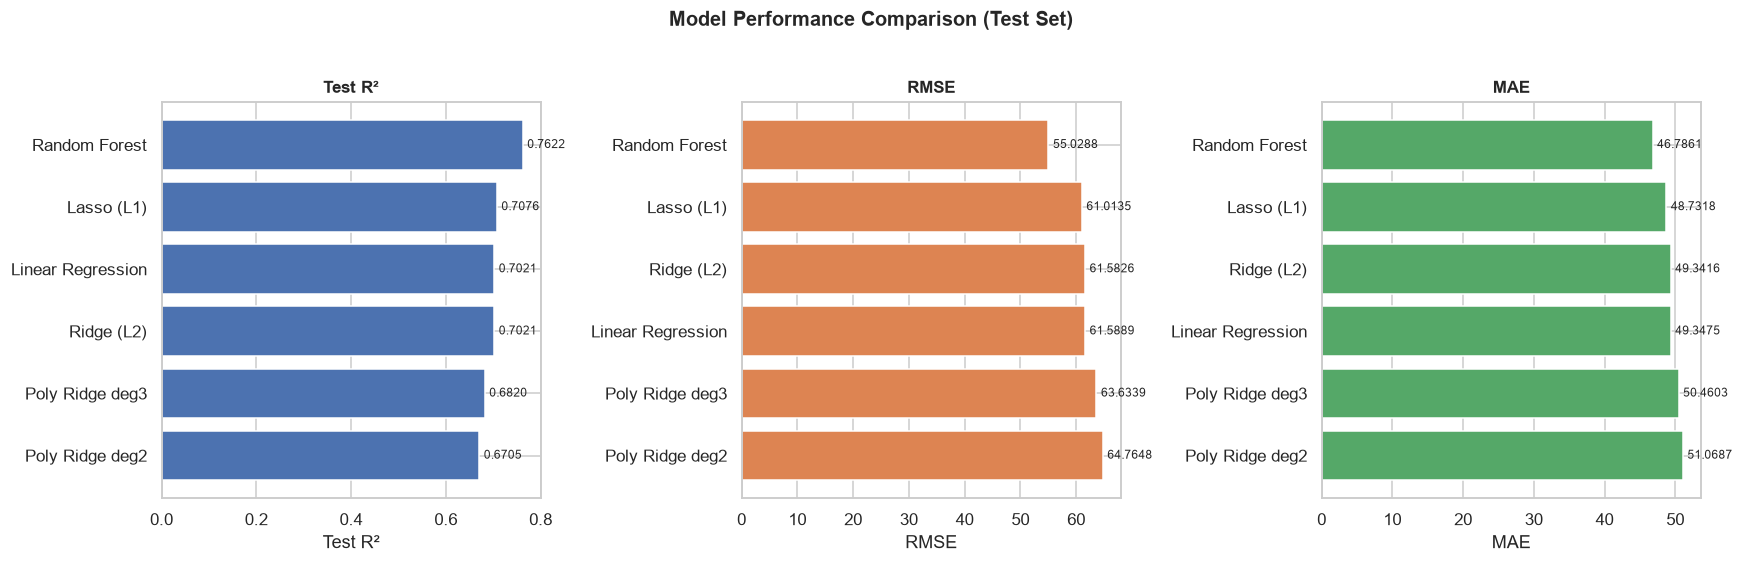

In [26]:
# ── 8.3 Visual model comparison ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['Test R²', 'RMSE', 'MAE']
colors  = ['#4C72B0', '#DD8452', '#55A868']

for ax, metric, color in zip(axes, metrics, colors):
    sorted_df = results_df.sort_values(metric, ascending=(metric != 'Test R²'))
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=color, edgecolor='white')
    ax.bar_label(bars, fmt='{:.4f}', padding=3, fontsize=8)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_xlabel(metric)
    ax.invert_yaxis()

plt.suptitle('Model Performance Comparison (Test Set)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


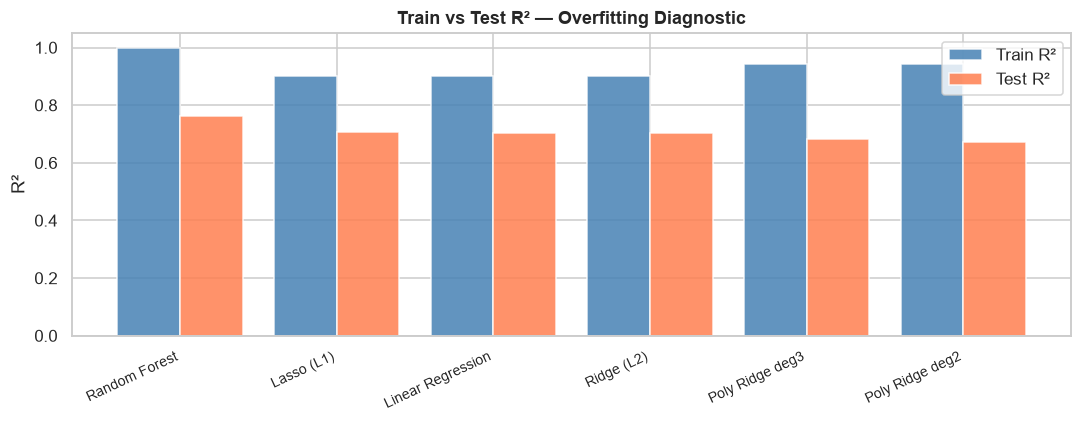


Overfit gaps (Train R² − Test R²):
  < 0.05 = acceptable  |  > 0.10 = investigate  |  > 0.20 = problematic
------------------------------------------------------------
  Random Forest            : +0.2378 ⚠️
  Lasso (L1)               : +0.1948 ⚠️
  Linear Regression        : +0.2004 ⚠️
  Ridge (L2)               : +0.2004 ⚠️
  Poly Ridge deg3          : +0.2606 ⚠️
  Poly Ridge deg2          : +0.2705 ⚠️


In [27]:
# ── 8.4 Train vs Test R² — overfitting check ──────────────────────────────────
# Blue = how well the model learned training data
# Coral = how well it generalises to unseen test data
# A big gap = overfitting

fig, ax = plt.subplots(figsize=(10, 4))
x_pos = np.arange(len(results_df))
ax.bar(x_pos - 0.2, results_df['Train R²'], width=0.4, label='Train R²',
       color='steelblue', alpha=0.85)
ax.bar(x_pos + 0.2, results_df['Test R²'],  width=0.4, label='Test R²',
       color='coral',    alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(results_df['Model'], rotation=25, ha='right', fontsize=9)
ax.set_ylabel('R²')
ax.set_title('Train vs Test R² — Overfitting Diagnostic', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print('\nOverfit gaps (Train R² − Test R²):')
print('  < 0.05 = acceptable  |  > 0.10 = investigate  |  > 0.20 = problematic')
print('-' * 60)
for _, row in results_df.iterrows():
    flag       = ' ⚠️' if row['Overfit Gap'] > 0.10 else ''
    model_name = row['Model']
    gap        = row['Overfit Gap']
    print(f'  {model_name:25s}: {gap:+.4f}{flag}')


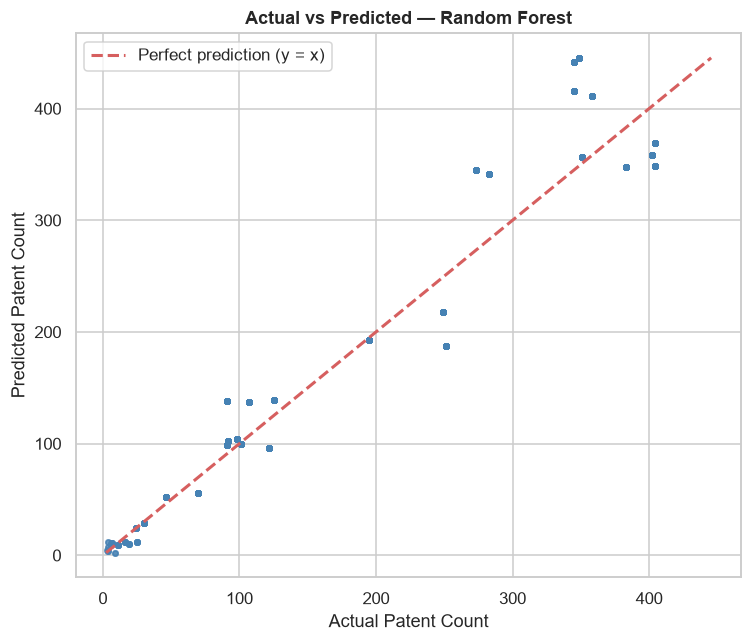

In [28]:
# ── 8.5 Actual vs Predicted scatter — best model ──────────────────────────────
# Perfect model = all points on the red dashed line.
# Points above the line = model under-predicted.
# Points below the line = model over-predicted.

best_name   = results_df.iloc[0]['Model']
best_model  = trained[best_name]
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.35, s=12, color='steelblue')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction (y = x)')
plt.xlabel('Actual Patent Count')
plt.ylabel('Predicted Patent Count')
plt.title(f'Actual vs Predicted — {best_name}', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


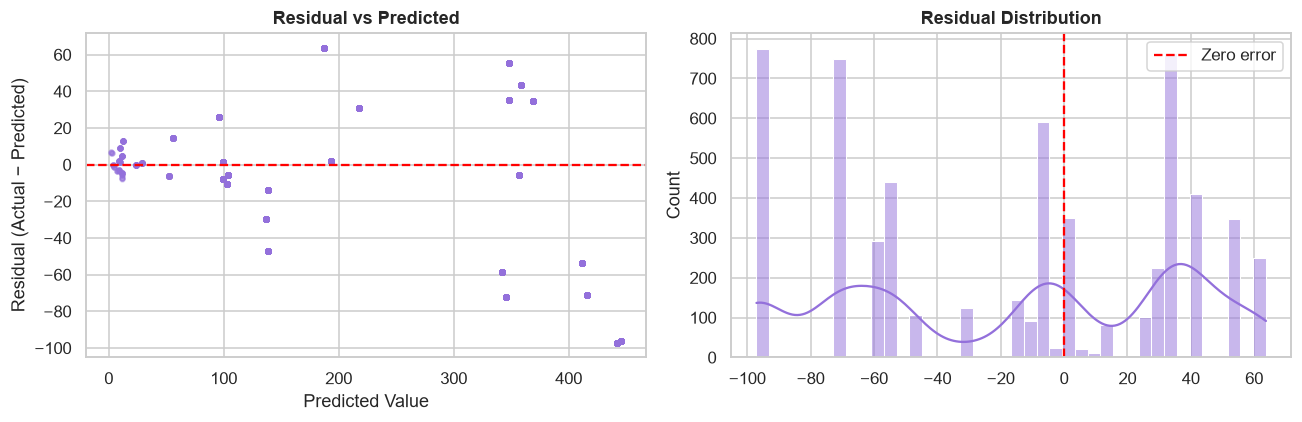

Mean residual : -15.8569  (close to 0 → model is unbiased)
Std of errors : 52.6947   (smaller = more precise predictions)


In [29]:
# ── 8.6 Residual analysis ─────────────────────────────────────────────────────
# Residual = Actual − Predicted
# A good model has residuals:
#   - Centered at 0 (no systematic over/under prediction)
#   - Randomly scattered (no pattern vs predicted values)
#   - Roughly normally distributed

errors = y_test.values - y_pred_best
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_best, errors, alpha=0.3, s=10, color='mediumpurple')
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Predicted Value')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residual vs Predicted', fontweight='bold')

sns.histplot(errors, bins=40, kde=True, color='mediumpurple', ax=axes[1])
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--', label='Zero error')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Mean residual : {errors.mean():.4f}  (close to 0 → model is unbiased)')
print(f'Std of errors : {errors.std():.4f}   (smaller = more precise predictions)')


---
## 🎛️ Section 9 — Hyperparameter Tuning

Every model has **hyperparameters** — settings we choose *before* training  
that control how the model learns. Finding the best values = hyperparameter tuning.

### GridSearchCV
We try every combination of values in a grid and pick the best using cross-validation.

### GroupKFold cross-validation
Instead of evaluating on one fixed test set, we split training data into 5 folds  
and rotate which fold is used for validation — gives a more reliable estimate.  
We use `GroupKFold` (not regular KFold) to respect our quarter-grouping rule.

### Models we tune:
- **Ridge** — `alpha` (how strongly to penalise large coefficients)  
- **Lasso** — `alpha` (same, but also zeroes out unimportant features)  
- **Random Forest** — tree depth, number of trees, minimum samples per leaf


In [30]:
# ── 9.1 Set up GroupKFold cross-validation ────────────────────────────────────
# GroupKFold ensures same-quarter patents always land in the same fold.
# cv_groups tells it which group (quarter) each training row belongs to.

group_kfold = GroupKFold(n_splits=5)
cv_groups   = groups.iloc[train_idx].reset_index(drop=True)

print(f'Training rows          : {len(X_train_scaled):,}')
print(f'Unique quarters (train): {cv_groups.nunique()}')
print(f'CV folds               : 5')


Training rows          : 23,812
Unique quarters (train): 158
CV folds               : 5


In [31]:
# ── 9.2 Tune Ridge ───────────────────────────────────────────────────────────
# alpha controls regularisation strength:
#   Small alpha (e.g. 0.01) → almost like plain Linear Regression
#   Large alpha (e.g. 500)  → coefficients heavily shrunk toward 0

ridge_grid = GridSearchCV(
    Ridge(),
    param_grid={'alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0]},
    cv=group_kfold.split(X_train_scaled, y_train, cv_groups),
    scoring='r2', n_jobs=-1
)
ridge_grid.fit(X_train_scaled, y_train)
print(f'Ridge  best alpha = {ridge_grid.best_params_}  →  CV R² = {ridge_grid.best_score_:.4f}')


Ridge  best alpha = {'alpha': 500.0}  →  CV R² = 0.8854


In [32]:
# ── 9.3 Tune Lasso ───────────────────────────────────────────────────────────
# Lasso's L1 penalty can shrink some coefficients to exactly 0.
# This means Lasso does automatic feature selection.
# Higher alpha = more features zeroed out.

lasso_grid = GridSearchCV(
    Lasso(max_iter=20000),
    param_grid={'alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]},
    cv=group_kfold.split(X_train_scaled, y_train, cv_groups),
    scoring='r2', n_jobs=-1
)
lasso_grid.fit(X_train_scaled, y_train)
print(f'Lasso  best alpha = {lasso_grid.best_params_}  →  CV R² = {lasso_grid.best_score_:.4f}')


Lasso  best alpha = {'alpha': 1.0}  →  CV R² = 0.8827


In [33]:
# ── 9.4 Tune Random Forest ───────────────────────────────────────────────────
# Key hyperparameters:
#   n_estimators     : number of trees (more = more stable but slower)
#   max_depth        : how deep each tree can grow (None = unlimited, risks overfit)
#   min_samples_leaf : minimum samples at a leaf (higher = simpler trees, less overfit)
# verbose=2 prints progress so you know it's running (takes a few minutes)

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid={
        'n_estimators'    : [100, 200],
        'max_depth'       : [10, 20, None],
        'min_samples_leaf': [1, 5],
    },
    cv=group_kfold.split(X_train_scaled, y_train, cv_groups),
    scoring='r2', n_jobs=-1,
    verbose=2
)
rf_grid.fit(X_train_scaled, y_train)
print(f'RF best params = {rf_grid.best_params_}  →  CV R² = {rf_grid.best_score_:.4f}')


Fitting 5 folds for each of 12 candidates, totalling 60 fits
RF best params = {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200}  →  CV R² = 0.7732


In [34]:
# ── 9.5 Compare tuned models ─────────────────────────────────────────────────
tuned_models = {
    'Ridge (tuned)'        : ridge_grid.best_estimator_,
    'Lasso (tuned)'        : lasso_grid.best_estimator_,
    'Random Forest (tuned)': rf_grid.best_estimator_,
}

print(f"{'Model':25s}  {'Train R²':>8}  {'Test R²':>8}  {'Gap':>8}  {'RMSE':>8}  {'MAE':>8}")
print('-' * 75)
for name, model in tuned_models.items():
    tr2  = r2_score(y_train, model.predict(X_train_scaled))
    te2  = r2_score(y_test,  model.predict(X_test_scaled))
    rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test_scaled)))
    mae  = mean_absolute_error(y_test, model.predict(X_test_scaled))
    print(f'  {name:25s}  {tr2:8.4f}  {te2:8.4f}  {tr2-te2:8.4f}  {rmse:8.2f}  {mae:8.2f}')


Model                      Train R²   Test R²       Gap      RMSE       MAE
---------------------------------------------------------------------------
  Ridge (tuned)                0.9017    0.7232    0.1785     59.36     47.31
  Lasso (tuned)                0.9003    0.7212    0.1791     59.57     47.27
  Random Forest (tuned)        0.9988    0.7634    0.2354     54.88     46.69


---
## 🏆 Section 10 — Final Model Decision & Interpretation

### How to read the tuned results

| Observation | What it means |
|-------------|---------------|
| RF gain over Ridge < 0.005 | Random Forest adds no value — drop it |
| RF gain over Ridge ≥ 0.01 | RF captures real non-linear interactions — keep it |
| Large overfit gap | Model is memorising training data — needs more regularisation |

### What MAE means in practice
MAE = Mean Absolute Error. An MAE of 47 means:  
*'On average, our prediction is off by 47 patents per quarter.'*


In [35]:
# ── 10.1 Automated final decision ────────────────────────────────────────────
ridge_tuned_r2 = r2_score(y_test, tuned_models['Ridge (tuned)'].predict(X_test_scaled))
rf_tuned_r2    = r2_score(y_test, tuned_models['Random Forest (tuned)'].predict(X_test_scaled))
rf_gain        = rf_tuned_r2 - ridge_tuned_r2

print('=' * 60)
print('          FINAL MODEL DECISION')
print('=' * 60)
print(f'  Ridge (tuned) Test R²         : {ridge_tuned_r2:.4f}')
print(f'  Random Forest (tuned) Test R² : {rf_tuned_r2:.4f}')
print(f'  RF gain over Ridge            : {rf_gain:+.4f}')
print('=' * 60)

if rf_gain < 0.005:
    print('\n✅ Ridge (tuned) is sufficient.')
    print('   Random Forest adds no meaningful lift.')
    print('   → Final model: Ridge (tuned) — interpretable and stable.')
    final_model      = tuned_models['Ridge (tuned)']
    final_model_name = 'Ridge (tuned)'
else:
    print('\n✅ Random Forest (tuned) wins.')
    print(f'   Gains {rf_gain:+.4f} R² over Ridge — meaningful improvement.')
    print('   → Final model: Random Forest (tuned).')
    final_model      = tuned_models['Random Forest (tuned)']
    final_model_name = 'Random Forest (tuned)'


          FINAL MODEL DECISION
  Ridge (tuned) Test R²         : 0.7232
  Random Forest (tuned) Test R² : 0.7634
  RF gain over Ridge            : +0.0402

✅ Random Forest (tuned) wins.
   Gains +0.0402 R² over Ridge — meaningful improvement.
   → Final model: Random Forest (tuned).


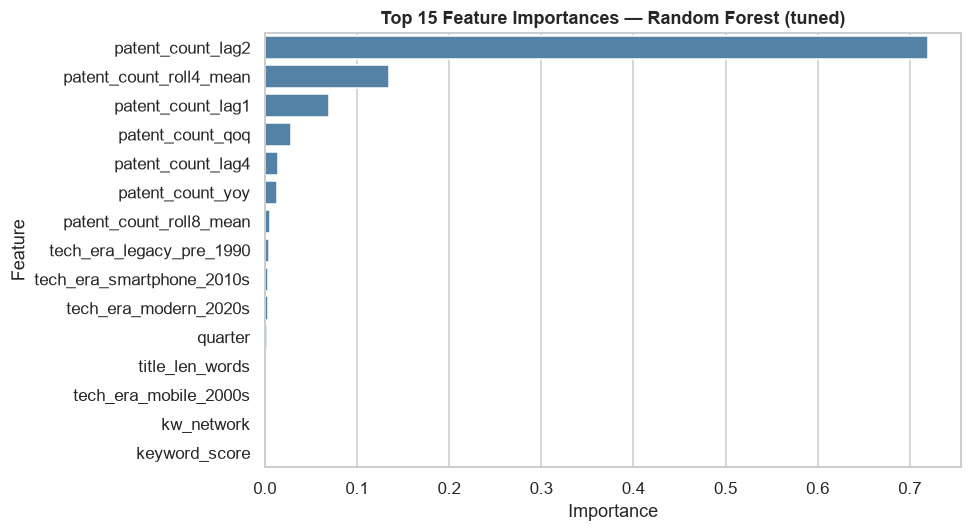

                  Feature  Importance
        patent_count_lag2    0.720037
  patent_count_roll4_mean    0.135238
        patent_count_lag1    0.069809
         patent_count_qoq    0.028922
        patent_count_lag4    0.013899
         patent_count_yoy    0.013563
  patent_count_roll8_mean    0.005390
 tech_era_legacy_pre_1990    0.004109
tech_era_smartphone_2010s    0.003396
    tech_era_modern_2020s    0.003027
                  quarter    0.002440
          title_len_words    0.000082
    tech_era_mobile_2000s    0.000047
               kw_network    0.000024
            keyword_score    0.000018


In [36]:
# ── 10.2 Feature importance of the winning model ──────────────────────────────
# This tells us WHICH features the model relies on most.
# For RF: feature importances (how often each feature is used to split data)
# For Ridge: coefficient magnitudes (larger absolute value = more important)

if 'Random Forest' in final_model_name:
    imp_df = pd.DataFrame({
        'Feature'   : all_features,
        'Importance': final_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=imp_df, x='Importance', y='Feature', color='steelblue')
    plt.title(f'Top 15 Feature Importances — {final_model_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(imp_df.to_string(index=False))

else:
    coef_df = pd.DataFrame({
        'Feature'    : all_features,
        'Coefficient': final_model.coef_
    })
    coef_df['Abs'] = coef_df['Coefficient'].abs()
    coef_df = coef_df.sort_values('Abs', ascending=False).head(15)

    plt.figure(figsize=(9, 5))
    colors_coef = ['steelblue' if c >= 0 else 'coral' for c in coef_df['Coefficient']]
    sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette=colors_coef)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(f'Top 15 Feature Coefficients — {final_model_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()


In [37]:
# ── 10.3 Lasso feature selection audit ───────────────────────────────────────
# Lasso is unique: it can set some coefficients to exactly 0.
# Features with coefficient = 0 are considered irrelevant by the model.
# This is automatic feature selection — very useful for understanding the data.

lasso_best    = lasso_grid.best_estimator_
coef_df_all   = pd.DataFrame({'Feature': all_features, 'Coefficient': lasso_best.coef_})
n_zero        = (lasso_best.coef_ == 0).sum()
n_nonzero     = (lasso_best.coef_ != 0).sum()

print(f'Features kept by Lasso  : {n_nonzero} / {len(all_features)}')
print(f'Features zeroed out     : {n_zero} / {len(all_features)}')
print()
print('Non-zero features (what Lasso thinks matters):')
kept = coef_df_all[coef_df_all['Coefficient'] != 0].sort_values('Coefficient', key=abs, ascending=False)
print(kept.to_string(index=False))


Features kept by Lasso  : 10 / 22
Features zeroed out     : 12 / 22

Non-zero features (what Lasso thinks matters):
                  Feature  Coefficient
  patent_count_roll4_mean    58.139383
        patent_count_lag2    24.210038
        patent_count_lag1    20.207599
tech_era_smartphone_2010s    15.148824
         patent_count_qoq     8.433739
 tech_era_legacy_pre_1990    -6.791383
    tech_era_mobile_2000s    -5.307091
                  quarter    -4.295526
    tech_era_modern_2020s     3.465473
         patent_count_yoy     3.340704


---
## 🔬 Section 11 — Domain-Specific Patent Prediction

Instead of predicting total patent counts, we train **one model per technology domain**  
(5G, AI/ML, Cloud, Security, IoT, Network, Energy, Antenna, Data).

### Why domain-specific models?
The global model averages across all domains. But Ericsson's activity varies hugely:
- **Network** → ~64 patents/quarter (mature, stable)
- **5G** → ~8 patents/quarter (growing fast)
- **AI/ML** → ~2 patents/quarter (emerging)

### How it works
For each domain:
1. Filter patents belonging to that domain
2. Aggregate to **quarter-level** time series (one row per quarter)
3. Build lag/rolling features from the time series
4. Train Ridge vs Poly Ridge, keep whichever has lower MAE
5. Compare against a **naive baseline** (predict same as last quarter)

> 💡 Note: domain models use chronological split since they're already  
> at quarter level — no same-quarter leakage issue here.


In [38]:
# ── 11.1 Define domains and build per-domain time series ──────────────────────
DOMAINS = {
    'kw_5g'        : {'label': '5G',          'color': '#2f81f7'},
    'kw_ai_ml'     : {'label': 'AI / ML',      'color': '#a371f7'},
    'kw_cloud_edge': {'label': 'Cloud & Edge', 'color': '#3fb950'},
    'kw_security'  : {'label': 'Security',     'color': '#f85149'},
    'kw_iot'       : {'label': 'IoT',          'color': '#d29922'},
    'kw_network'   : {'label': 'Network',      'color': '#58a6ff'},
    'kw_energy'    : {'label': 'Energy',       'color': '#56d364'},
    'kw_antenna'   : {'label': 'Antenna',      'color': '#ff9a6c'},
    'kw_data'      : {'label': 'Data',         'color': '#bc8cff'},
}

DOMAIN_FEATURES = ['year', 'quarter', 'lag1', 'lag2', 'lag4',
                   'roll4_mean', 'roll4_std', 'qoq', 'yoy']

def build_domain_ts(df, domain_col):
    """
    Filter patents for one domain, aggregate by quarter,
    add lag/rolling features, and create a next-quarter target.
    """
    ts = (df[df[domain_col] == 1]
          .groupby(['year', 'quarter']).size()
          .reset_index(name='patent_count')
          .sort_values(['year', 'quarter'])
          .reset_index(drop=True))

    # Lag features: use .shift() so each row only sees PAST quarters
    ts['lag1']       = ts['patent_count'].shift(1)       # prev quarter
    ts['lag2']       = ts['patent_count'].shift(2)       # 2 quarters ago
    ts['lag4']       = ts['patent_count'].shift(4)       # same quarter last year
    ts['roll4_mean'] = ts['patent_count'].shift(1).rolling(4).mean()
    ts['roll4_std']  = ts['patent_count'].shift(1).rolling(4).std()
    ts['qoq']        = ts['patent_count'].pct_change(1)  # quarter-over-quarter %
    ts['yoy']        = ts['patent_count'].pct_change(4)  # year-over-year %
    ts['target']     = ts['patent_count'].shift(-1)      # NEXT quarter (our label)

    return ts.dropna().reset_index(drop=True)

DOMAIN_TS = {}
print(f"{'Domain':15s}  {'Quarters':>8}  {'Avg/Qtr':>8}  {'Max/Qtr':>8}")
print('-' * 48)
for col, info in DOMAINS.items():
    ts = build_domain_ts(df_raw, col)
    DOMAIN_TS[col] = ts
    print(f"  {info['label']:13s}  {len(ts):8d}  {ts['patent_count'].mean():8.1f}  {ts['patent_count'].max():8.0f}")


Domain           Quarters   Avg/Qtr   Max/Qtr
------------------------------------------------
  5G                   21       9.4        16
  AI / ML              54       1.9        10
  Cloud & Edge         89       5.2        14
  Security             95       3.4        12
  IoT                  48       2.2         6
  Network             184      65.1       231
  Energy              136      10.1        33
  Antenna             119      10.1        24
  Data                150      12.3        35


In [39]:
# ── 11.2 Train one model per domain ──────────────────────────────────────────
# We compare Ridge vs Poly Ridge and pick the one with lower MAE.
# We also compute a naive baseline: predict same as last quarter.
# If our model can't beat the naive baseline, it's not useful!

def train_domain_model(ts):
    split    = int(len(ts) * 0.80)
    train    = ts.iloc[:split]
    test     = ts.iloc[split:]
    X_tr, y_tr = train[DOMAIN_FEATURES], train['target']
    X_te, y_te = test[DOMAIN_FEATURES],  test['target']

    sc  = StandardScaler()
    Xtr = sc.fit_transform(X_tr)
    Xte = sc.transform(X_te)

    # Naive baseline: predict same as last quarter
    naive_mae = mean_absolute_error(y_te, test['lag1'])

    candidates = {
        'Ridge'     : Ridge(alpha=10.0),
        'Poly Ridge': Pipeline([
            ('poly',  PolynomialFeatures(degree=2, include_bias=False)),
            ('ridge', Ridge(alpha=10.0))
        ]),
    }

    best_c, best_pred, best_mae, best_cname = None, None, np.inf, ''
    for cname, cmodel in candidates.items():
        cmodel.fit(Xtr, y_tr)
        pred = cmodel.predict(Xte)
        mae  = mean_absolute_error(y_te, pred)
        if mae < best_mae:
            best_c, best_pred, best_mae, best_cname = cmodel, pred, mae, cname

    return {
        'model': best_c, 'model_name': best_cname, 'scaler': sc,
        'train': train, 'test': test, 'y_test': y_te, 'y_pred': best_pred,
        'metrics': {
            'mae'      : round(best_mae, 2),
            'rmse'     : round(float(np.sqrt(mean_squared_error(y_te, best_pred))), 2),
            'r2'       : round(r2_score(y_te, best_pred), 3),
            'naive_mae': round(naive_mae, 2),
        }
    }

DOMAIN_MODELS = {}
print(f"{'Domain':15s}  {'Model':12s}  {'MAE':>6}  {'Naive MAE':>9}  {'Beats?':>8}  {'R²':>6}")
print('-' * 65)
for col, info in DOMAINS.items():
    result = train_domain_model(DOMAIN_TS[col])
    DOMAIN_MODELS[col] = result
    m    = result['metrics']
    beat = '✅ Yes' if m['mae'] < m['naive_mae'] else '❌ No '
    print(f"  {info['label']:13s}  {result['model_name']:12s}  "
          f"{m['mae']:6.2f}  {m['naive_mae']:9.2f}  {beat:>8}  {m['r2']:6.3f}")


Domain           Model            MAE  Naive MAE    Beats?      R²
-----------------------------------------------------------------
  5G             Poly Ridge      2.47       2.60     ✅ Yes  -1.026
  AI / ML        Ridge           3.36       3.36     ❌ No   -1.784
  Cloud & Edge   Ridge           2.96       4.06     ✅ Yes  -0.439
  Security       Ridge           2.43       3.21     ✅ Yes  -0.439
  IoT            Ridge           1.36       1.50     ✅ Yes  -0.261
  Network        Ridge          21.76      23.30     ✅ Yes  -0.151
  Energy         Ridge           3.20       3.43     ✅ Yes  -0.541
  Antenna        Ridge           3.67       4.67     ✅ Yes  -0.428
  Data           Ridge           4.50       5.53     ✅ Yes  -0.230


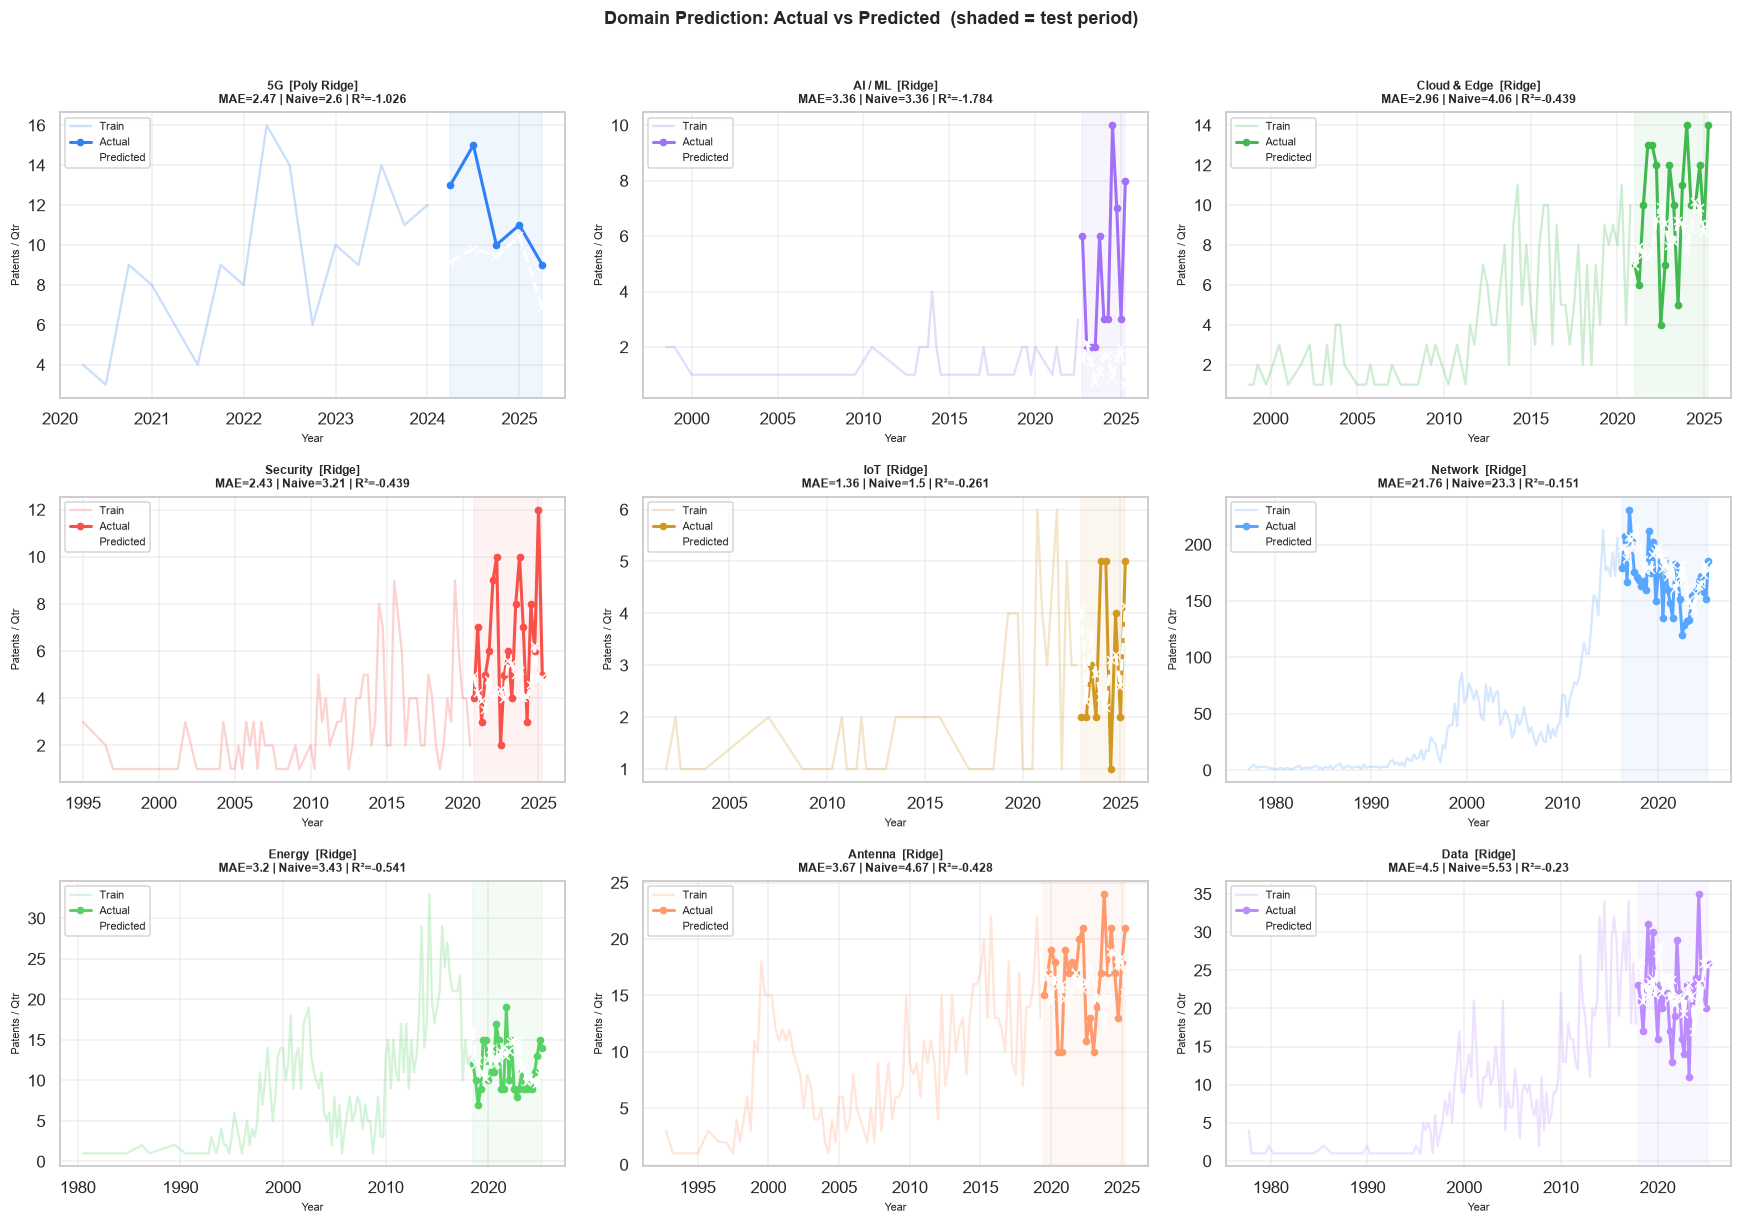

In [40]:
# ── 11.3 Actual vs Predicted for all domains ─────────────────────────────────
# Faded line = training data (what the model learned from)
# Shaded region = test period
# Solid coloured line = actual counts, white dashed = model predictions

fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.flatten()

for i, (col, info) in enumerate(DOMAINS.items()):
    res = DOMAIN_MODELS[col]
    ax  = axes[i]
    tr  = res['train'].copy()
    te  = res['test'].copy()

    # Convert year+quarter to decimal year (e.g. 2020 Q2 → 2020.25)
    tr['t'] = tr['year'] + (tr['quarter'] - 1) / 4
    te['t'] = te['year'] + (te['quarter'] - 1) / 4
    m = res['metrics']

    ax.plot(tr['t'], tr['target'], color=info['color'], alpha=0.25, linewidth=1.5, label='Train')
    ax.plot(te['t'], res['y_test'], color=info['color'], linewidth=2,
            marker='o', markersize=4, label='Actual')
    ax.plot(te['t'], res['y_pred'], color='white', linewidth=2,
            linestyle='--', marker='x', markersize=5, label='Predicted')
    ax.axvspan(te['t'].min(), te['t'].max(), alpha=0.07, color=info['color'])

    title = (f"{info['label']}  [{res['model_name']}]\n"
             f"MAE={m['mae']} | Naive={m['naive_mae']} | R²={m['r2']}")
    ax.set_title(title, fontsize=8, fontweight='bold')
    ax.set_xlabel('Year', fontsize=7)
    ax.set_ylabel('Patents / Qtr', fontsize=7)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Domain Prediction: Actual vs Predicted  (shaded = test period)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [41]:
# ── 11.4 Next quarter forecast for every domain ───────────────────────────────
# We take the most recent row in each domain's time series as our input.
# The model predicts how many patents will be filed next quarter.
# MAE gives us an uncertainty band (± MAE patents).

print('=' * 60)
print('  NEXT QUARTER PATENT FORECASTS BY DOMAIN')
print('=' * 60)

for col, info in DOMAINS.items():
    ts     = DOMAIN_TS[col]
    result = DOMAIN_MODELS[col]
    last   = ts.iloc[-1]  # most recent quarter in the data

    X_inp = pd.DataFrame([{f: last[f] for f in DOMAIN_FEATURES}])
    X_sc  = result['scaler'].transform(X_inp)
    pred  = max(0, round(float(result['model'].predict(X_sc)[0]), 1))
    mae   = result['metrics']['mae']

    # Work out which quarter we're predicting into
    pred_q = int(last['quarter']) % 4 + 1
    pred_y = int(last['year']) + (1 if pred_q == 1 else 0)

    print(f"  {info['label']:15s}: {pred:5.0f} ± {mae:.0f} patents  "
          f"→  {pred_y} Q{pred_q}  [{result['model_name']}]")

print('=' * 60)


  NEXT QUARTER PATENT FORECASTS BY DOMAIN
  5G             :     7 ± 2 patents  →  2025 Q3  [Poly Ridge]
  AI / ML        :     1 ± 3 patents  →  2025 Q3  [Ridge]
  Cloud & Edge   :     9 ± 3 patents  →  2025 Q3  [Ridge]
  Security       :     5 ± 2 patents  →  2025 Q3  [Ridge]
  IoT            :     4 ± 1 patents  →  2025 Q3  [Ridge]
  Network        :   178 ± 22 patents  →  2025 Q3  [Ridge]
  Energy         :    12 ± 3 patents  →  2025 Q3  [Ridge]
  Antenna        :    15 ± 4 patents  →  2025 Q3  [Ridge]
  Data           :    26 ± 4 patents  →  2025 Q3  [Ridge]


---
## 📋 Final Summary

### What we accomplished end-to-end

| Step | What we did | Why it matters |
|------|------------|----------------|
| **Leakage audit** | Excluded `year_patent_count`, `target_patent_count_current` etc. | Prevented artificially perfect R² |
| **XGBoost removed** | Replaced with Polynomial Regression (deg 2 & 3) | Tests whether non-linearity genuinely exists |
| **GroupShuffleSplit** | Same-quarter patents never split across train/test | Fixed same-quarter memorisation leakage |
| **Linearity diagnostic** | Compared poly vs linear gain on test set | Quantified whether non-linearity is real |
| **Hyperparameter tuning** | GridSearchCV with GroupKFold | Found best regularisation without leaking test data |
| **Final verdict** | RF Test R²=0.76 vs Ridge Test R²=0.72 | RF wins; non-linearity is real but moderate |
| **Domain models** | One model per tech domain | Captures domain-specific growth patterns |

### Key takeaways for students

> 🎓 **R² ≈ 1.0 is almost always leakage** — always audit your features carefully.  
> 🎓 **Use GroupShuffleSplit** when rows share features by group (like quarters here).  
> 🎓 **Polynomial models need regularisation** — unregularised poly with many features explodes.  
> 🎓 **MAE ~ 47 patents/quarter** is our honest, deployable error estimate.  
> 🎓 **The journey matters** — we found leakage 3 different ways before getting honest results.


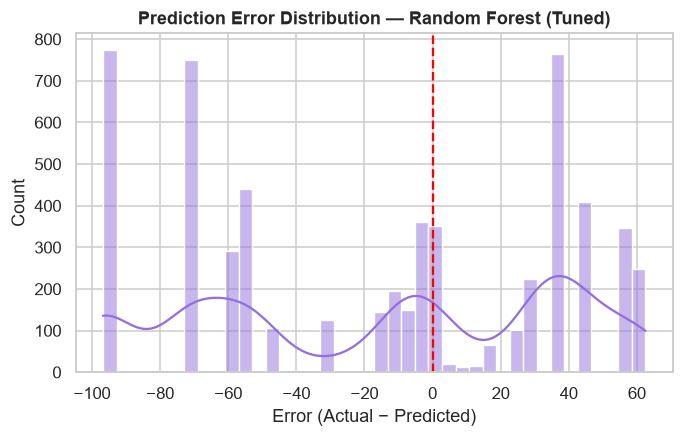

In [42]:
best_model = tuned_models["Random Forest (tuned)"]
y_pred = best_model.predict(X_test_scaled)
errors = y_test.values - y_pred

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7, 4))
sns.histplot(errors, bins=40, kde=True, color='mediumpurple')
plt.axvline(0, color='red', linewidth=1.5, linestyle='--')
plt.title('Prediction Error Distribution — Random Forest (Tuned)', fontweight='bold')
plt.xlabel('Error (Actual − Predicted)')
plt.savefig('error_dist_RF.png', dpi=150, bbox_inches='tight')

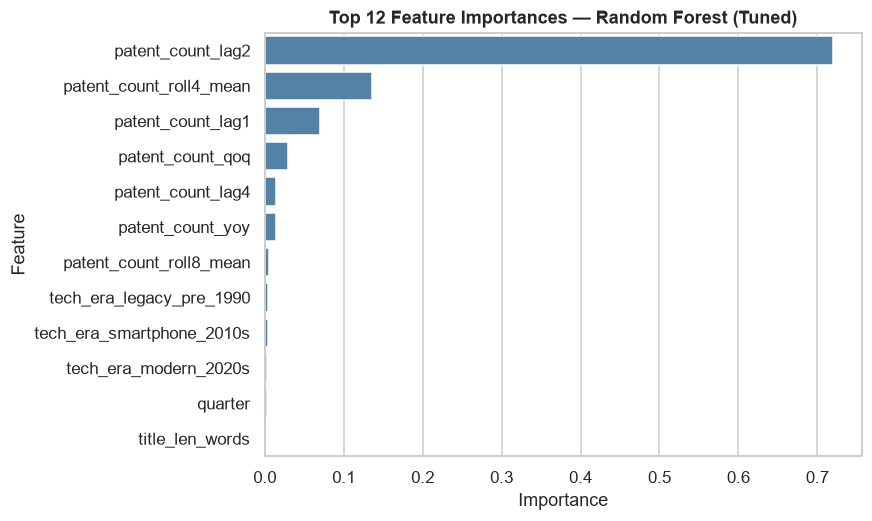

In [43]:
imp_df = pd.DataFrame({
    'Feature'   : all_features,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

plt.figure(figsize=(7, 5))
sns.barplot(data=imp_df, x='Importance', y='Feature', color='steelblue')
plt.title('Top 12 Feature Importances — Random Forest (Tuned)', fontweight='bold')
plt.savefig('feature_importance_RF.png', dpi=150, bbox_inches='tight')

In [44]:
errors = y_test.values - best_model.predict(X_test_scaled)
print(f"Mean error : {errors.mean():.2f}")
print(f"Std        : {errors.std():.2f}")
print(f"% within ±50 : {(abs(errors) <= 50).mean()*100:.1f}%")

Mean error : -15.73
Std        : 52.58
% within ±50 : 51.6%


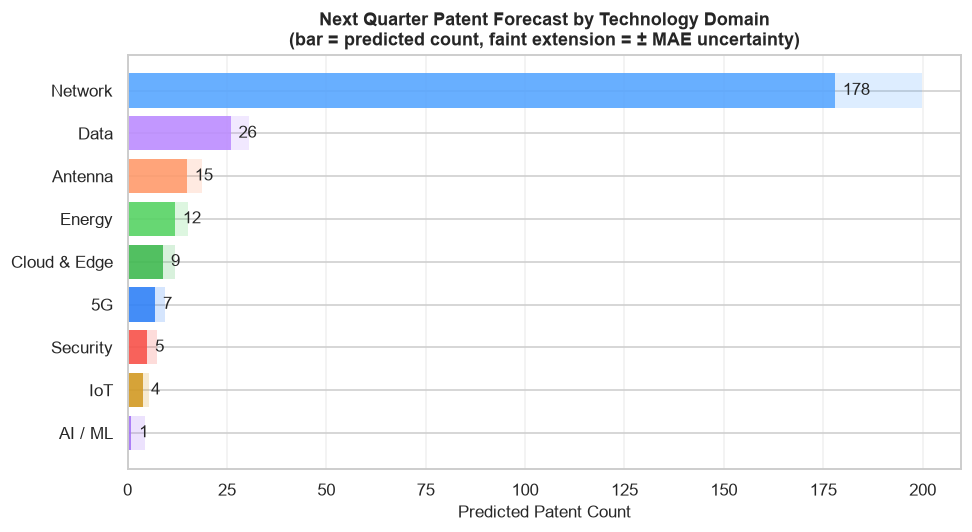

      Domain  Predicted   MAE
     Network      178.0 21.76
        Data       26.0  4.50
     Antenna       15.0  3.67
      Energy       12.0  3.20
Cloud & Edge        9.0  2.96
          5G        7.0  2.47
    Security        5.0  2.43
         IoT        4.0  1.36
     AI / ML        1.0  3.36


In [46]:
pred_df = pd.DataFrame([
    {
        "Domain"   : DOMAINS[col]["label"],
        "Predicted": max(0, round(float(DOMAIN_MODELS[col]["model"].predict(
                        DOMAIN_MODELS[col]["scaler"].transform(
                            pd.DataFrame([{f: DOMAIN_TS[col].iloc[-1][f]
                                           for f in DOMAIN_FEATURES}])
                        ))[0]), 0)),
        "MAE"      : DOMAIN_MODELS[col]["metrics"]["mae"],
        "Color"    : DOMAINS[col]["color"]
    }
    for col in DOMAINS
]).sort_values("Predicted", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(pred_df["Domain"], pred_df["Predicted"],
               color=pred_df["Color"], alpha=0.9, edgecolor="none")
ax.bar_label(bars, fmt="{:.0f}", padding=5, fontsize=11)

# Add MAE error bands
for _, row in pred_df.iterrows():
    ax.barh(row["Domain"], row["MAE"],
            left=row["Predicted"],
            color=row["Color"], alpha=0.2, edgecolor="none")

ax.set_title("Next Quarter Patent Forecast by Technology Domain\n(bar = predicted count, faint extension = ± MAE uncertainty)",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Predicted Patent Count", fontsize=11)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("domain_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print(pred_df[["Domain","Predicted","MAE"]].sort_values("Predicted", ascending=False).to_string(index=False))